In [27]:
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt

In [28]:
def rev_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    while b - a > dx:
        x = 0.5 * (a + b)
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return 0.5 * (a + b)

def rev_discrete_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    x = (a + b) // 2
    while b - a > 1:
        x = (a + b) // 2
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return b

In [29]:
def generate_variables(p, N, F1, F2):
    N = int(N)
    W1 = np.random.standard_normal(N)
    W2 = np.random.standard_normal(N)
    Z1 = W1
    Z2 = p * W1 + np.sqrt(1 - p**2) * W2

    U1 = sc.norm.cdf(Z1)
    U2 = sc.norm.cdf(Z2)
    X1 = np.empty(N)
    X2 = np.empty(N)

    for k in range(N):
        X1[k] = rev_distr(F1, U1[k])
        X2[k] = rev_distr(F2, U2[k])
    
    return (X1, X2)

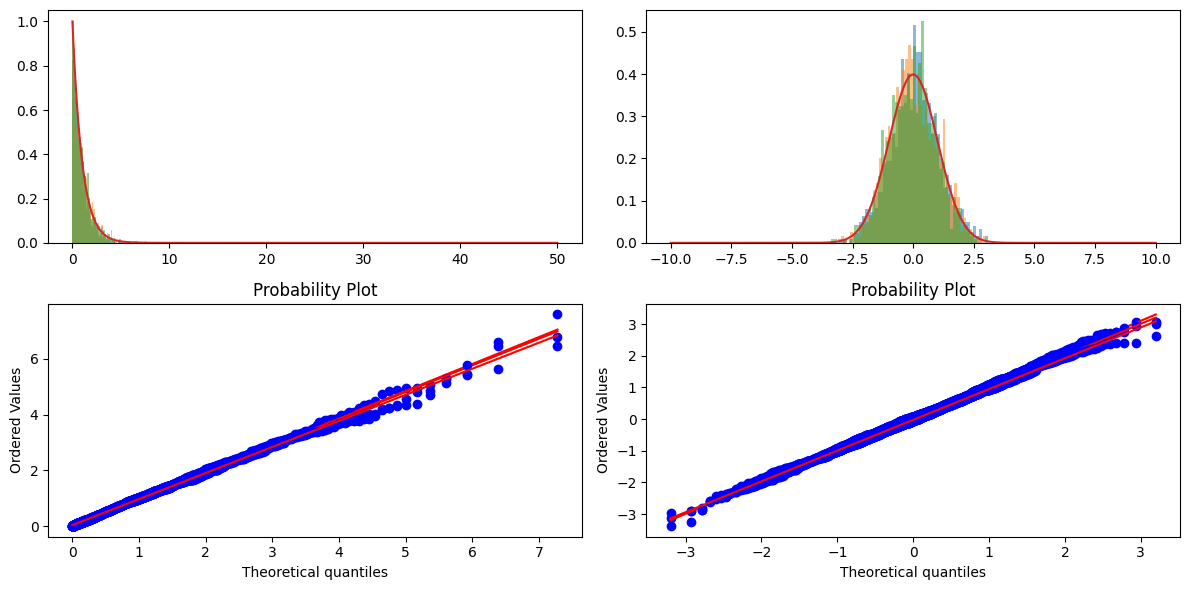

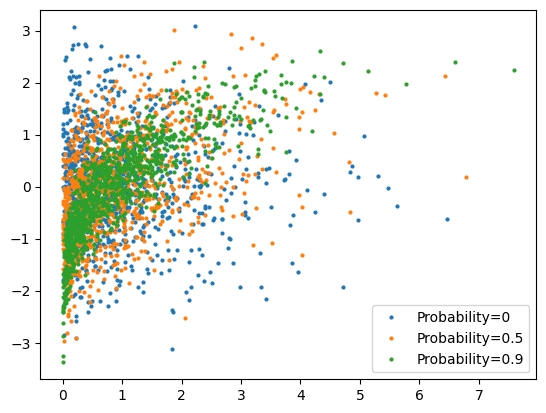

Współczynnik korelacji wynosi 0, korelacja Spearmana: 0.012
Współczynnik korelacji wynosi 0.5, korelacja Spearmana: 0.462
Współczynnik korelacji wynosi 0.9, korelacja Spearmana: 0.886


In [30]:
f1 = sc.expon.cdf
f2 = sc.norm.cdf

probability_set = [0, 0.5, 0.9]
N = 1000
x1_data = []
x2_data = []

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i in range(len(probability_set)):
    x1, x2 = generate_variables(probability_set[i], N, f1, f2)
    x1_data.append(x1)
    x2_data.append(x2)
    axes[0, 0].hist(x1, density=True, alpha=0.5, bins=50)
    axes[0, 1].hist(x2, density=True, alpha=0.5, bins=50)
    sc.probplot(x1, dist='expon', plot=axes[1, 0])
    sc.probplot(x2, dist='norm', plot=axes[1, 1])

x_norm = np.linspace(-10, 10, 1000)
y_norm = sc.norm.pdf(x_norm)
x_exp = np.linspace(0, 50, 1000)
y_exp = sc.expon.pdf(x_exp, scale=1)

axes[0, 0].plot(x_exp, y_exp)
axes[0, 1].plot(x_norm, y_norm)

plt.tight_layout()
plt.show()

spear_c = []
for i in range (len(probability_set)):
    s_c = sc.spearmanr(x1_data[i], x2_data[i]).statistic
    spear_c.append(s_c)
    plt.plot(x1_data[i], x2_data[i], 'o', markersize=2, label=f'Probability={probability_set[i]}')
    plt.legend()

plt.show()

for i in range(3):
    print(f'Współczynnik korelacji wynosi {probability_set[i]}, korelacja Spearmana: {spear_c[i]:.3f}')
